#**Week 5 Day 1**



1.	Scaling: StandardScaler, MinMaxScaler, RobustScaler  implement each, test on skewed data
2.	When to scale: tree models don't need it, linear/NN models do
3.	Encoding: OrdinalEncoder, OneHotEncoder : implement target encoding with CV to prevent leakage


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")

In [9]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [11]:
null_cols = df.isnull().sum()
null_cols[null_cols > 0].sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [12]:
#drop cols > 50% null count
df = df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType"])

In [13]:
#Fill na values of numeric columns with median
for cols in df.select_dtypes(include='number').columns:
  df[cols] = df[cols].fillna(df[cols].median())

In [14]:
#fill categorical columns with mode
for cols in df.select_dtypes(include='object').columns:
  df[cols] = df[cols].fillna(df[cols].mode()[0])

In [15]:
#encode categoricals with pd.get_dummies()
df = pd.get_dummies(df)

In [16]:
X = df.drop(columns=['SalePrice'])
y=df['SalePrice']

In [17]:
print(f"X shape: {X.shape}")
print(f"\ny shape: {y.shape}")

X shape: (1460, 272)

y shape: (1460,)


### Task 1
1. Implement all three scalers on a single skewed feature (use SalePrice or LotArea from House Prices).
2. Print mean and std before and after each.
3. What does each one guarantee about the output distribution?


In [24]:
#StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import StandardScaler

print("MEAN before StandardScaler", y.mean())
print("SD before StandardScaler", y.std(),"\n")

scaler = StandardScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1,1))

print("Mean after StandardScaler ",y_scaled.mean())
print("SD after StandardScaler ",y_scaled.std())


MEAN before StandardScaler 180921.19589041095
SD before StandardScaler 79442.50288288663 

Mean after StandardScaler  1.3626846987180004e-16
SD after StandardScaler  0.9999999999999998


1. Mean and std are both pulled by outliers. A $2M mansion drags the mean up and inflates the std, so every other house gets scaled relative to a distorted centre.(StandardScaler)

2. Median and IQR ignore the tails entirely, the median doesn't move when you add an extreme value, and IQR only looks at the middle 50% of data. So outliers get compressed rather than dominating the scale. (RobustScaler)

In [29]:
#MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

print("MEAN before StandardScaler", y.mean())
print("SD before StandardScaler", y.std(),"\n")

scaler_m = MinMaxScaler()
y_scaled_min = scaler_m.fit_transform(y.values.reshape(-1,1))


print("MEAN after StandardScaler", y_scaled_min.mean())
print("SD after StandardScaler", y_scaled_min.std(),"\n")

MEAN before StandardScaler 180921.19589041095
SD before StandardScaler 79442.50288288663 

MEAN after StandardScaler 0.20277905275713232
SD after StandardScaler 0.11028369932796486 



In [31]:
#RobustScaler
from sklearn.preprocessing import RobustScaler

print("MEAN before RobustScaler", y.mean())
print("SD before RobustScaler", y.std(),"\n")

scaler_r = RobustScaler()
y_scaledR = scaler_r.fit_transform(y.values.reshape(-1,1))

print("MEAN after RobustScaler", y_scaledR.mean())
print("SD after RobustScaler", y_scaledR.std(),"\n")


MEAN before StandardScaler 180921.19589041095
SD before StandardScaler 79442.50288288663 

MEAN after StandardScaler 0.21328409271539375
SD after StandardScaler 0.9451388501763462 



## Task 2  
1. Visual comparison Plot the same feature's distribution (histogram) before scaling and after each of the three scalers 4 plots side by side.


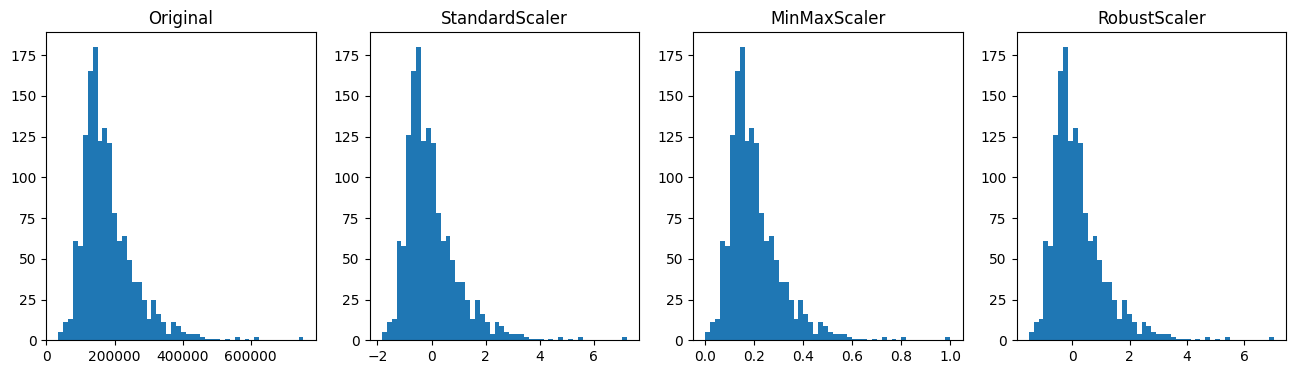

In [38]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,4,figsize=(16,4))
ax[0].hist(y, bins=50)
ax[0].set_title("Original")

ax[1].hist(y_scaled.flatten(),bins=50)
ax[1].set_title("StandardScaler")


ax[2].hist(y_scaled_min.flatten(),bins=50)
ax[2].set_title("MinMaxScaler")

ax[3].hist(y_scaledR.flatten(),bins=50)
ax[3].set_title("RobustScaler")
plt.show()

##Task 3
1. OrdinalEncoder vs OneHotEncoder
2. Create a small toy DataFrame with an ordered column (Low/Medium/High) and an unordered one (Red/Blue/Green).
3. Apply the right encoder to each. Print results.


In [39]:
df_toy = pd.DataFrame({
    'quality': ['Low', 'High', 'Medium', 'High', 'Low'],
    'colour':['Red', 'Blue', 'Green', 'Red', 'Blue']
})

In [45]:
#OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

encode = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])

encode.fit_transform(df_toy['quality'].values.reshape(-1,1))

array([[0.],
       [2.],
       [1.],
       [2.],
       [0.]])

1. Ordinal Encoder: implies order (0 < 1 < 2), so it's only appropriate when the categories actually have a ranking (e.g. Low < Medium < High).
2. For unordered categories like male/female, OneHotEncoder is correct.
3. Using OrdinalEncoder on unordered data tells the model there's a ranking that doesn't exist.

In [47]:
#OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()

enc.fit_transform(df_toy['colour'].values.reshape(-1,1)).toarray()

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

## Task 4
1. Target encoding with CV This is the new concept.
2. Encode a categorical feature using the mean of the target variable per category but do it inside a cross-validation loop to prevent leakage.


In [50]:
df_encode = pd.read_csv('train.csv')


## Target Encoding
1. Replace the categorical column with mean of the Target Variable


        - if houses in neighbourhood "A" have average SalePrice $200k,
        - Replace A with 200,000
2. Leakage

        - If you calculate the mean using the full dataset including your validation rows,
        - the model sees target information it shouldn't have during training. That's leakage.

3. The fix

        - Calculate target means only on training folds, apply to validation fold. Hence "with CV."

In [51]:
# categorical column and its unique count
df_encode.select_dtypes(include='object').nunique().sort_values(ascending=False)

,0
Neighborhood,25
Exterior2nd,16
Exterior1st,15
Condition1,9
SaleType,9
HouseStyle,8
RoofMatl,8
Condition2,8
Functional,7
BsmtFinType2,6


In [52]:
from sklearn.model_selection import KFold

target_col = 'SalePrice'
encode_col = 'Neighborhood'


kf = KFold(n_splits=5, shuffle=True,random_state=42)
df_encode['Neighborhood_encoded'] = np.nan


for train_idx, val_idx in kf.split(df_encode):
  train_fold = df_encode.iloc[train_idx]
  val_fold = df_encode.iloc[val_idx]

  # calculate mean SalePrice per Neighborhood on training fold only
  means = train_fold.groupby('Neighborhood')['SalePrice'].mean()

  # map means onto validation fold
  df_encode.loc[df_encode.index[val_idx], 'Neighborhood_encoded'] = \
        val_fold['Neighborhood'].map(means)

print(df_encode[['Neighborhood', 'Neighborhood_encoded']].head(10))

  Neighborhood  Neighborhood_encoded
0      CollgCr         197484.352941
1      Veenker         226333.333333
2      CollgCr         197484.352941
3      Crawfor         216567.282051
4      NoRidge         346306.303030
5      Mitchel         159636.108108
6      Somerst         226809.892308
7       NWAmes         188041.465517
8      OldTown         125893.736264
9      BrkSide         125387.790698


## Task 5
Markdown When would you use each scaler? One line each. When does target encoding beat OneHotEncoder?

## Scalers
- StandardScaler:Scale data with mean =0, std =1
- MinMaxScaler: Scale data into the range (0,1)
- RobustScaler: Apply median and not mean, use IQR to not fluctuate the data due to outliers.  

## Encoders
- OrdinalEncoder: For ordered data, applies ranking
- OneHotEncoder: Unordered data, wehre no ranking is needed
- Target Encoding:Replace a feature by mean of the target variable. to prevent leakage use kFold on training only

## When does target encoding beat OneHotEncoder?
- Large number of unique values in features and OneHotEncoder may be extremely large

## Scalers
- StandardScaler: Removes mean, scales to unit variance (mean=0, std=1).
  Use for linear models, SVMs, neural networks.
- MinMaxScaler: Compresses to [0,1] range. Use when bounded range is needed
  e.g. image pixel values, neural network inputs.
- RobustScaler: Uses median and IQR ignores outliers. Use when data has
  significant outliers that would distort mean/std.
- Rule: Tree models (RF, XGBoost, LightGBM) need NO scaling.
  Linear/NN models DO need scaling.

## Encoders
- OrdinalEncoder: Ordered categories only (Low < Medium < High).
  Preserves rank relationship.
- OneHotEncoder: Unordered categories. Creates one binary column per
  unique value. No ranking implied.
- Target Encoding: Replaces category with mean target value per category.
  Must be calculated inside CV folds (training fold only) to prevent
  leakage into validation set.

## When does target encoding beat OneHotEncoder?
High cardinality features (nunique > 10-15) where OneHotEncoder would
create too many sparse columns. e.g. Neighborhood (25 unique values) →
target encoding adds one dense column vs 25 sparse binary columns.